# Pipeline de pre-processamento — placas veiculares

Este notebook aplica, imagem a imagem, as correcoes recomendadas em `eda_pre_process.ipynb`:
gamma automatico (baixa luz / estourada), CLAHE (baixo contraste), non-local means (ruidosa),
unsharp mask (desfocada) e upscaling Lanczos (placa pequena).

Cada imagem so recebe as correcoes que os seus proprios limiares de qualidade indicam serem
necessarias — nao existe um unico filtro aplicado em bloco a tudo. A logica de decisao e as
funcoes de correcao vivem em `preprocessing_pipeline.py` (modulo importavel e testavel de forma
independente do notebook).

In [1]:
import sys
import sqlite3
from pathlib import Path

import cv2
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from preprocessing_pipeline import process_folder, compute_metrics, parse_ccpd_bbox

## Execucao do pipeline sobre as 100 imagens

In [2]:
df = process_folder("images", "images_processed", "images_processed/mapping.db")
print(df.shape)
df.head()

(100, 21)


,original_filename,processed_filename,original_path,processed_path,flag_baixa_luz,flag_estourada,flag_baixo_contraste,flag_desfocada,flag_ruidosa,flag_placa_pequena,...,brightness_mean_before,brightness_mean_after,contrast_std_before,contrast_std_after,sharpness_laplacian_var_before,sharpness_laplacian_var_after,noise_estimate_before,noise_estimate_after,plate_area_ratio_before,plate_area_ratio_after
0,0023-2_2-286&531_360&558-360&558_286&555_286&5...,0023-2_2-286&531_360&558-360&558_286&555_286&5...,images/0023-2_2-286&531_360&558-360&558_286&55...,images_processed/0023-2_2-286&531_360&558-360&...,False,False,False,False,True,True,...,92.331331,91.037574,52.813252,51.498265,1461.615308,223.244063,0.876969,0.488142,0.002392,0.002422
1,0040-0_0-358&514_457&548-457&548_358&547_358&5...,0040-0_0-358&514_457&548-457&548_358&547_358&5...,images/0040-0_0-358&514_457&548-457&548_358&54...,images_processed/0040-0_0-358&514_457&548-457&...,False,True,True,False,True,True,...,110.076946,94.233042,32.021101,34.528452,596.391210,86.398780,0.390609,0.512971,0.004030,0.004017
2,0045-3_5-370&540_468&579-468&579_371&573_370&5...,0045-3_5-370&540_468&579-468&579_371&573_370&5...,images/0045-3_5-370&540_468&579-468&579_371&57...,images_processed/0045-3_5-370&540_468&579-468&...,True,False,True,False,True,True,...,46.174516,56.354211,27.029698,29.507952,270.112514,40.388767,0.320993,0.531147,0.004576,0.004537
3,0046-0_6-320&466_430&501-430&501_324&501_320&4...,0046-0_6-320&466_430&501-430&501_324&501_320&4...,images/0046-0_6-320&466_430&501-430&501_324&50...,images_processed/0046-0_6-320&466_430&501-430&...,False,False,True,False,True,True,...,58.095584,91.253730,30.431310,38.901661,1126.065734,369.942120,0.574152,0.684990,0.004610,0.004566
4,0047-0_1-285&527_389&565-389&565_286&565_285&5...,0047-0_1-285&527_389&565-389&565_286&565_285&5...,images/0047-0_1-285&527_389&565-389&565_286&56...,images_processed/0047-0_1-285&527_389&565-389&...,False,False,True,False,True,True,...,74.900051,101.294197,27.628672,44.482642,558.161946,150.261862,0.910886,0.574152,0.004732,0.004732


In [3]:
df["corrections_applied"].value_counts()

corrections_applied
baixa_luz,baixo_contraste,desfocada                  30
baixa_luz,baixo_contraste                             7
estourada,baixo_contraste,placa_pequena               6
estourada,baixo_contraste                             6
baixo_contraste,placa_pequena                         5
estourada                                             5
estourada,baixo_contraste,desfocada                   5
ruidosa,estourada,placa_pequena                       4
ruidosa,estourada                                     4
ruidosa,estourada,baixo_contraste,placa_pequena       3
ruidosa,baixa_luz,baixo_contraste,placa_pequena       3
ruidosa,baixo_contraste,placa_pequena                 3
baixo_contraste                                       3
estourada,desfocada                                   3
baixo_contraste,desfocada                             3
ruidosa,placa_pequena                                 2
ruidosa,baixa_luz,baixo_contraste                     2
desfocada                   

## Checagens de integridade (arquivo em disco, nao so o DataFrame em memoria)

In [4]:
original_files = sorted(Path("images").glob("*.jpg"))
processed_files = sorted(Path("images_processed").glob("*.jpg"))
print(f"Originais: {len(original_files)} | Processadas: {len(processed_files)}")
assert len(processed_files) == len(original_files) == 100
assert {f.name for f in original_files} == {f.name for f in processed_files}
print("OK: mesma quantidade e mesmos nomes de arquivo em images/ e images_processed/")

Originais: 100 | Processadas: 100
OK: mesma quantidade e mesmos nomes de arquivo em images/ e images_processed/


In [5]:
conn = sqlite3.connect("images_processed/mapping.db")
row_count = conn.execute("SELECT COUNT(*) FROM image_mapping").fetchone()[0]
print("Linhas na tabela image_mapping (lido do arquivo .db, nao da memoria):", row_count)
assert row_count == 100

schema = conn.execute("PRAGMA table_info(image_mapping)").fetchall()
for col in schema:
    print(col)
conn.close()

Linhas na tabela image_mapping (lido do arquivo .db, nao da memoria): 100
(0, 'id', 'INTEGER', 0, None, 0)
(1, 'original_filename', 'TEXT', 0, None, 0)
(2, 'processed_filename', 'TEXT', 0, None, 0)
(3, 'original_path', 'TEXT', 0, None, 0)
(4, 'processed_path', 'TEXT', 0, None, 0)
(5, 'flag_baixa_luz', 'INTEGER', 0, None, 0)
(6, 'flag_estourada', 'INTEGER', 0, None, 0)
(7, 'flag_baixo_contraste', 'INTEGER', 0, None, 0)
(8, 'flag_desfocada', 'INTEGER', 0, None, 0)
(9, 'flag_ruidosa', 'INTEGER', 0, None, 0)
(10, 'flag_placa_pequena', 'INTEGER', 0, None, 0)
(11, 'corrections_applied', 'TEXT', 0, None, 0)
(12, 'brightness_mean_before', 'REAL', 0, None, 0)
(13, 'brightness_mean_after', 'REAL', 0, None, 0)
(14, 'contrast_std_before', 'REAL', 0, None, 0)
(15, 'contrast_std_after', 'REAL', 0, None, 0)
(16, 'sharpness_laplacian_var_before', 'REAL', 0, None, 0)
(17, 'sharpness_laplacian_var_after', 'REAL', 0, None, 0)
(18, 'noise_estimate_before', 'REAL', 0, None, 0)
(19, 'noise_estimate_after', 

## Distribuicao de correcoes por imagem

Quantas correcoes cada imagem recebeu (0 = boa qualidade, sem alteracao; 2+ = multiplos problemas simultaneos). Essa distribuicao e a evidencia de que o pipeline se adapta a cada imagem em vez de aplicar um tratamento unico.

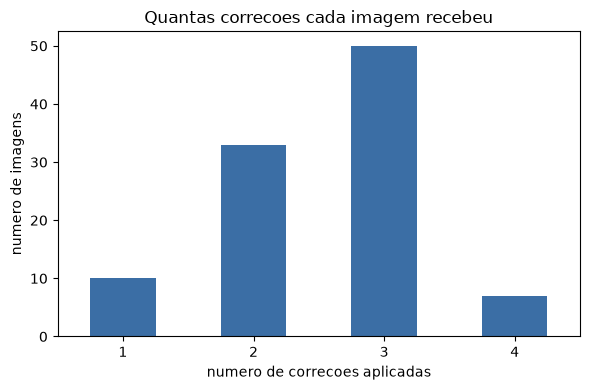

corrections_applied
1    10
2    33
3    50
4     7
Name: count, dtype: int64


In [6]:
n_corrections = df["corrections_applied"].apply(lambda s: 0 if s == "" else len(s.split(",")))
counts = n_corrections.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_xlabel("numero de correcoes aplicadas")
ax.set_ylabel("numero de imagens")
ax.set_title("Quantas correcoes cada imagem recebeu")
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

print(counts)

## Comparacao antes/depois — amostras representativas

Uma imagem por combinacao de correcao (so ruido, gamma+contraste, todas as correcoes, e uma boa_qualidade sem alteracao), com as metricas objetivas de antes/depois impressas — nao e uma avaliacao so visual.

--- gamma + contraste (0191-2_20-237&519_459&591-459&591_257&581_237&519_439&529-0_0_33_30_32_5_29-39-3.jpg) ---
brilho:     41.4 -> 95.5
contraste:  11.8 -> 27.3
nitidez:    68.2 -> 436.8
ruido:      0.0000 -> 0.9878

--- 4 correcoes (0040-0_0-358&514_457&548-457&548_358&547_358&514_457&515-0_0_8_4_33_26_29-119-4.jpg) ---
brilho:     110.1 -> 94.2
contraste:  32.0 -> 34.5
nitidez:    596.4 -> 86.4
ruido:      0.3906 -> 0.5130



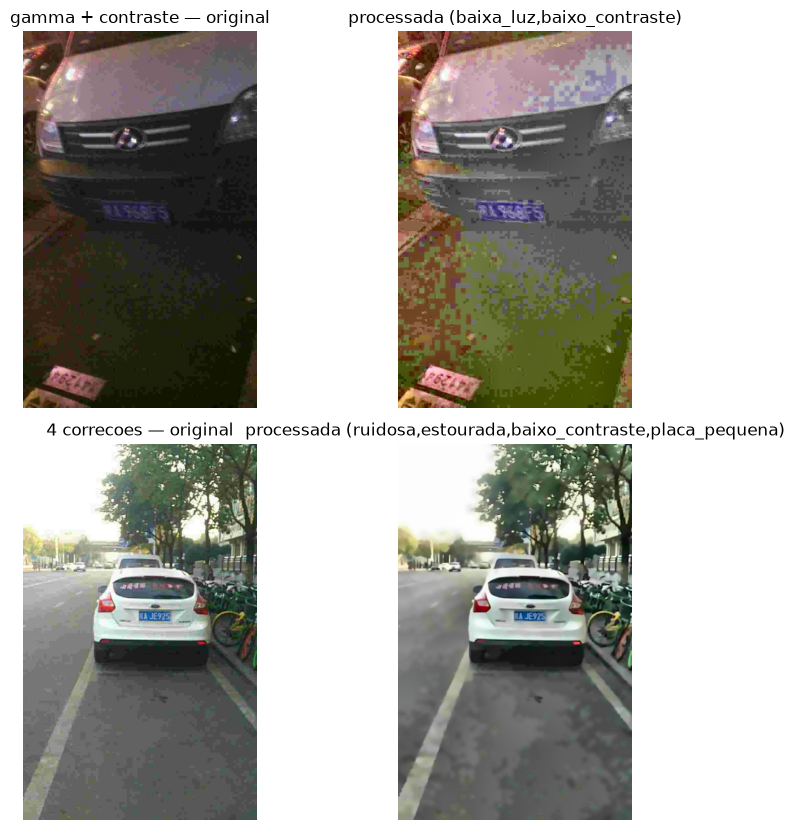

In [7]:
def pick_example(mask):
    subset = df[mask]
    return subset.iloc[0] if len(subset) else None

examples = {
    "so ruidosa": pick_example(df["corrections_applied"] == "ruidosa"),
    "gamma + contraste": pick_example(df["corrections_applied"].isin(["baixa_luz,baixo_contraste", "estourada,baixo_contraste"])),
    "4 correcoes": pick_example(n_corrections == 4),
    "boa_qualidade (sem alteracao)": pick_example(df["corrections_applied"] == ""),
}
examples = {k: v for k, v in examples.items() if v is not None}

fig, axes = plt.subplots(len(examples), 2, figsize=(9, 4.2 * len(examples)))
if len(examples) == 1:
    axes = axes.reshape(1, 2)

for row, (label, rec) in enumerate(examples.items()):
    orig = cv2.cvtColor(cv2.imread(rec["original_path"]), cv2.COLOR_BGR2RGB)
    proc = cv2.cvtColor(cv2.imread(rec["processed_path"]), cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"{label} — original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(proc)
    axes[row, 1].set_title(f"processada ({rec['corrections_applied'] or 'sem correcao'})")
    axes[row, 1].axis("off")

    print(f"--- {label} ({rec['original_filename']}) ---")
    print(f"brilho:     {rec['brightness_mean_before']:.1f} -> {rec['brightness_mean_after']:.1f}")
    print(f"contraste:  {rec['contrast_std_before']:.1f} -> {rec['contrast_std_after']:.1f}")
    print(f"nitidez:    {rec['sharpness_laplacian_var_before']:.1f} -> {rec['sharpness_laplacian_var_after']:.1f}")
    print(f"ruido:      {rec['noise_estimate_before']:.4f} -> {rec['noise_estimate_after']:.4f}")
    print()

fig.tight_layout()
plt.show()

## Conclusao

O pipeline rodou de ponta a ponta sobre as 100 imagens de `images/`, com cada imagem recebendo
apenas as correcoes indicadas pelos seus proprios limiares de qualidade (0 a 4 correcoes por
imagem, conforme a distribuicao acima). As imagens processadas estao em `images_processed/`,
com os mesmos nomes de arquivo das originais, e a relacao completa imagem original <-> imagem
processada (incluindo diagnostico, correcoes aplicadas e metricas antes/depois) esta persistida
em `images_processed/mapping.db`, tabela `image_mapping`.